# Exploratory Data Analysis (EDA)

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# load data-set

# cleveland

In [50]:
# Load the dataset
df = pd.read_csv("data/processed/cleveland_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# data analysis

In [51]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

Rows: 303, Columns: 14



In [52]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [53]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [54]:
total = len(df)
healthy_count = (df["target"] == 0).sum()
disease_count = (df["target"] == 1).sum()

healthy_pct = (healthy_count / total) * 100
disease_pct = (disease_count / total) * 100

print(f"Healthy %: {healthy_pct:.2f}%")
print(f"Heart Disease %: {disease_pct:.2f}%\n")

Healthy %: 54.13%
Heart Disease %: 45.87%



# visulivation 

C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\333541168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


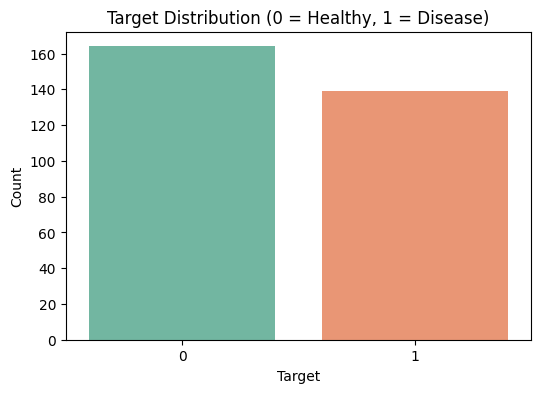

In [55]:
# Task: Target Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Target Distribution (0 = Healthy, 1 = Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

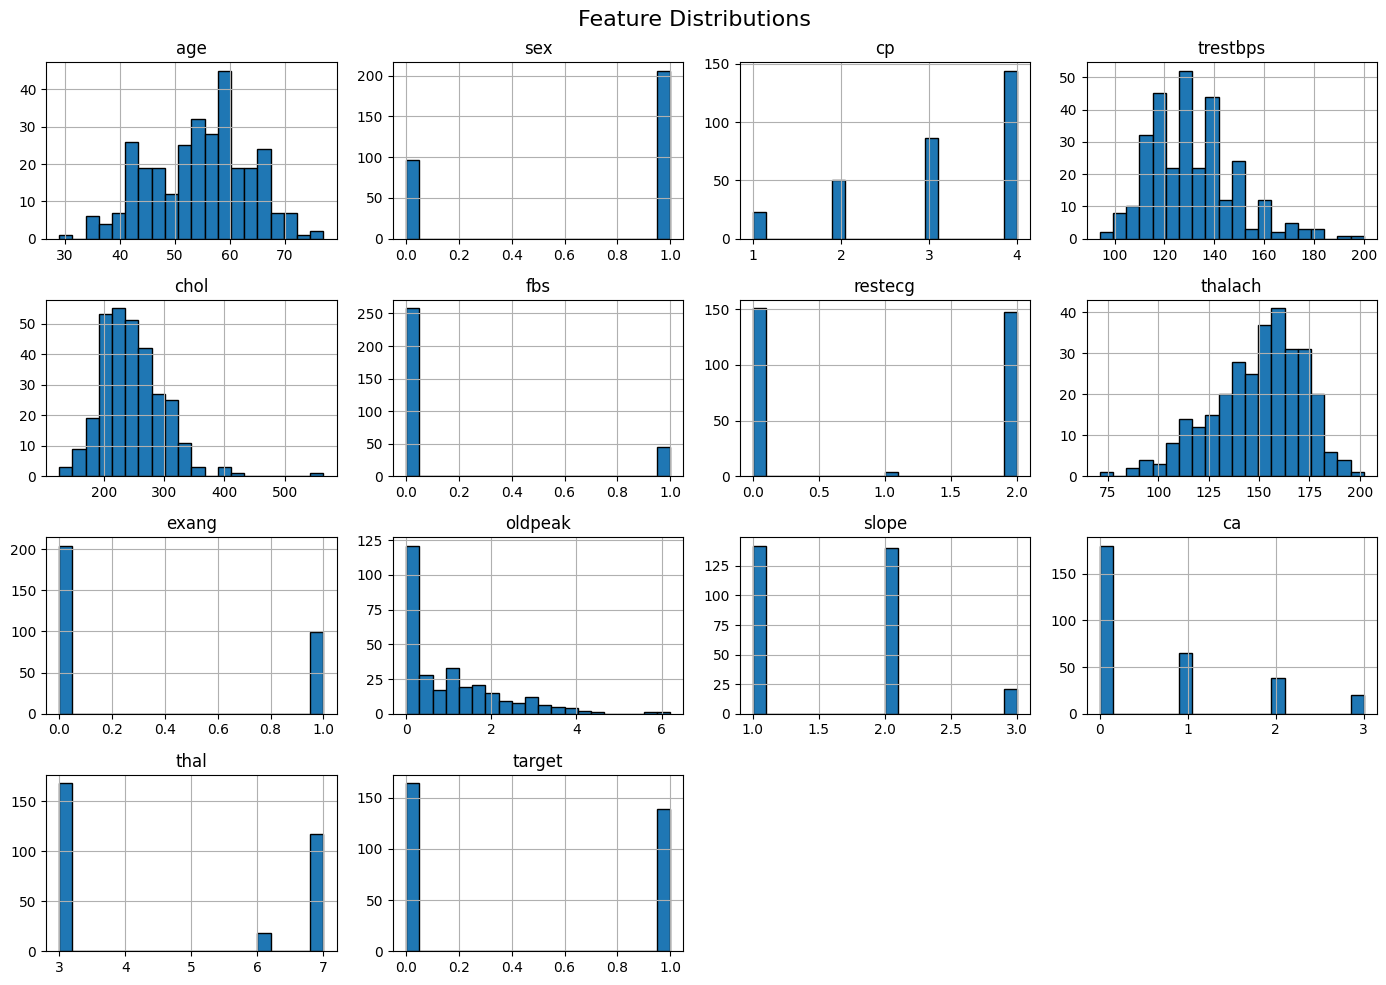

In [56]:
# Task: Feature Distributions (Histograms)
df.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [57]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,0.128303,0.223120
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,0.380581,0.276816
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233117,0.262089,0.414446
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,0.134424,0.150825
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,0.018351,0.085164
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,0.064625,0.025264
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,0.024325,0.169202
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,-0.274142,-0.417167
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,0.325240,0.431894
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,0.342405,0.424510


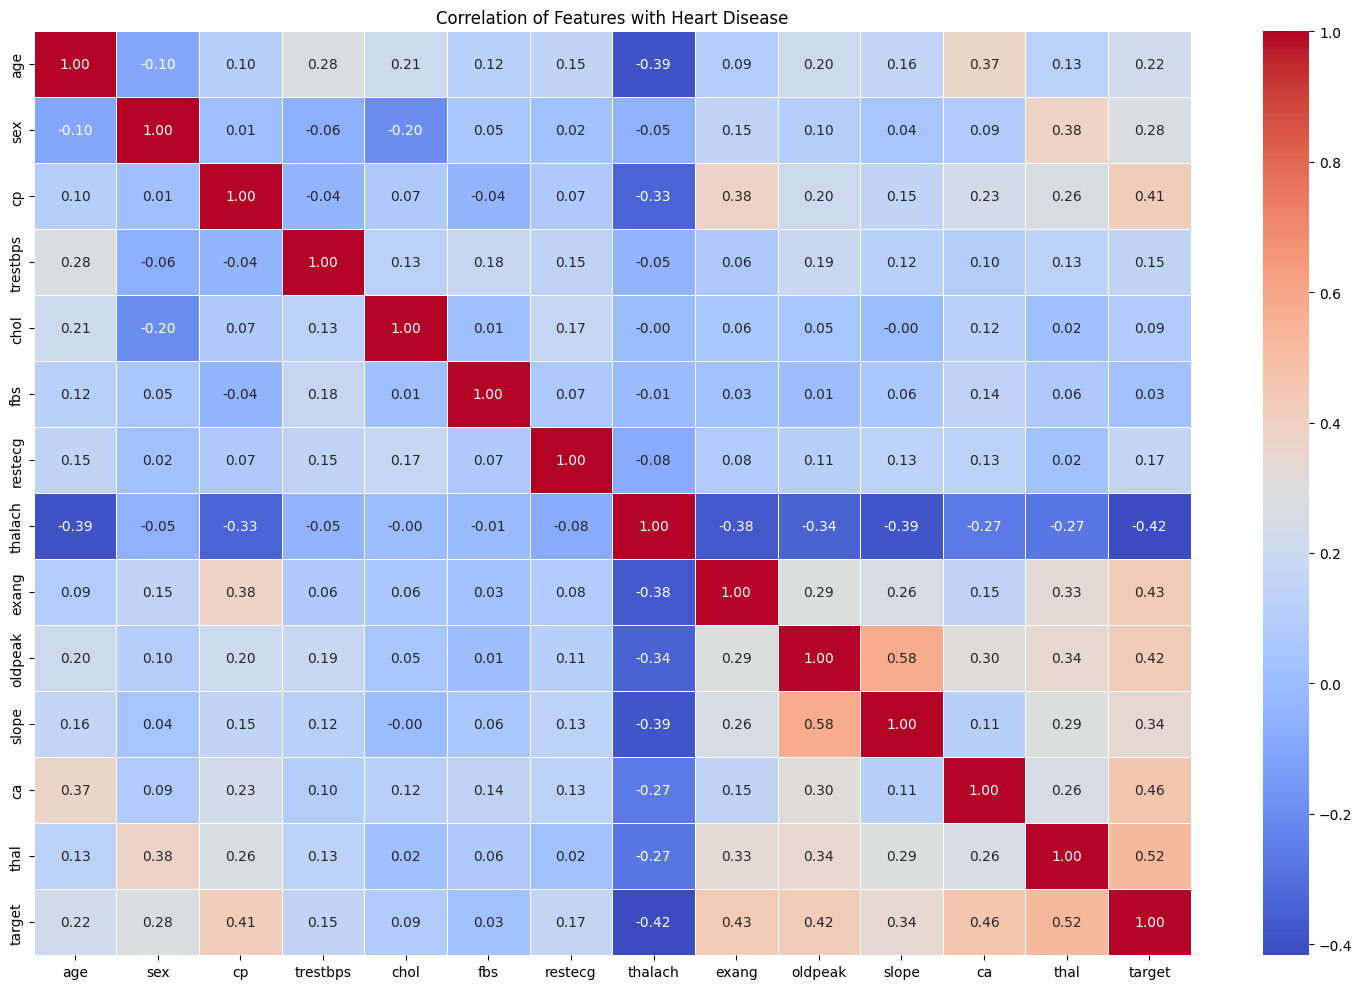

In [58]:
# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('Correlation of Features with Heart Disease')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()
     

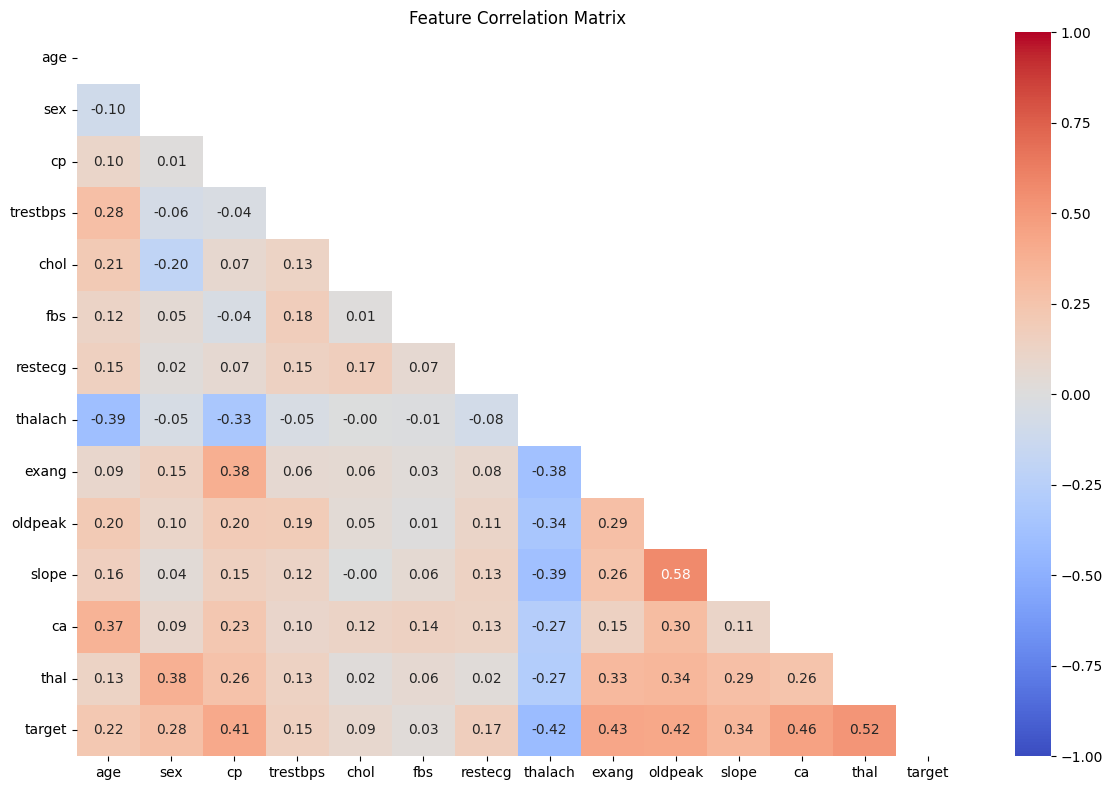

In [59]:
plt.figure(figsize=(12, 8))
# Creating a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(
    df.corr(), annot=True, fmt=".2f", cmap="coolwarm", mask=mask, vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\1104004845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="age", data=df, palette="Pastel1")


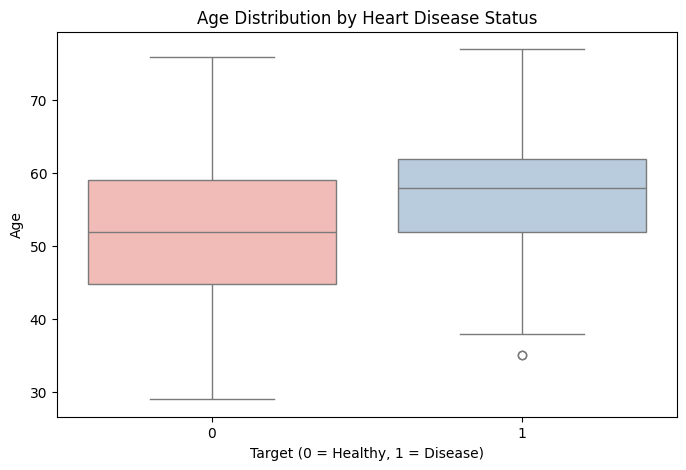

In [60]:
# Bonus: Age vs Target (to check your example observation)
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="age", data=df, palette="Pastel1")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Target (0 = Healthy, 1 = Disease)")
plt.ylabel("Age")
plt.show()

# Hungarian

In [61]:
# Load the dataset
df2 = pd.read_csv("data/processed/hungarian_clean.csv")
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,2.0,0.0,7.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,2.0,0.0,7.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,2.0,0.0,7.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,2.0,0.0,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,2.0,0.0,7.0,0


In [62]:
print(f"Rows: {df2.shape[0]}, Columns: {df2.shape[1]}\n")

Rows: 294, Columns: 14



In [63]:
df2["target"].value_counts()

target
0    188
1    106
Name: count, dtype: int64

In [64]:
df2.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [65]:
total = len(df2)
healthy_count = (df2["target"] == 0).sum()
disease_count = (df2["target"] == 1).sum()

healthy_pct = (healthy_count / total) * 100
disease_pct = (disease_count / total) * 100

print(f"Healthy %: {healthy_pct:.2f}%")
print(f"Heart Disease %: {disease_pct:.2f}%\n")

Healthy %: 63.95%
Heart Disease %: 36.05%



C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\598765972.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df2, palette="Set2")


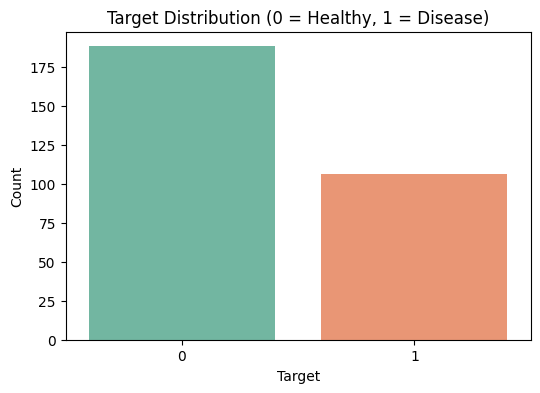

In [66]:
# Task: Target Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df2, palette="Set2")
plt.title("Target Distribution (0 = Healthy, 1 = Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


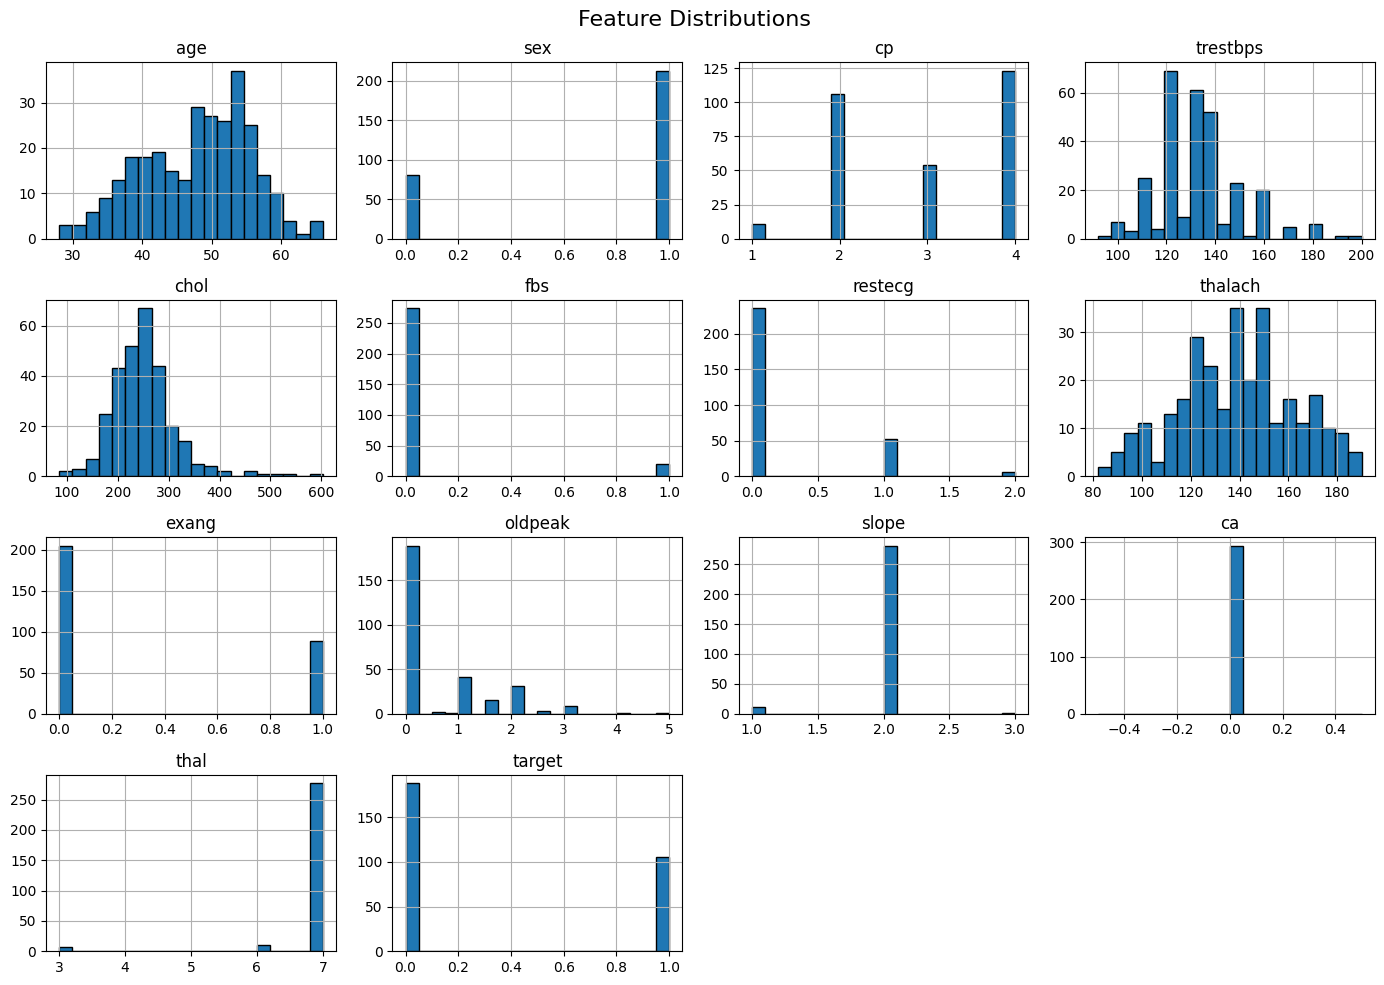

In [67]:
# Task: Feature Distributions (Histograms)
df2.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [68]:
df2.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,0.013618,0.145826,0.245183,0.086355,0.180962,0.050407,-0.459416,0.238698,0.177707,-0.092549,NaN,0.064557,0.159315
sex,0.013618,1.000000,0.249875,0.089519,0.028167,0.045663,-0.105503,-0.111482,0.157761,0.118931,0.109250,NaN,-0.041854,0.272781
cp,0.145826,0.249875,1.000000,0.085986,0.135515,0.032810,-0.014687,-0.369909,0.495723,0.353109,0.116234,NaN,-0.059556,0.505864
trestbps,0.245183,0.089519,0.085986,1.000000,0.079408,0.097277,0.012309,-0.184973,0.214020,0.205201,-0.016540,NaN,0.079722,0.139953
chol,0.086355,0.028167,0.135515,0.079408,1.000000,0.108554,0.050778,-0.121550,0.163551,0.109371,0.034861,NaN,-0.049192,0.205087
fbs,0.180962,0.045663,0.032810,0.097277,0.108554,1.000000,0.048400,-0.070477,0.116010,0.063722,0.114134,NaN,0.033929,0.162869
restecg,0.050407,-0.105503,-0.014687,0.012309,0.050778,0.048400,1.000000,0.004884,0.042309,0.043192,-0.021660,NaN,-0.020269,-0.031988
thalach,-0.459416,-0.111482,-0.369909,-0.184973,-0.121550,-0.070477,0.004884,1.000000,-0.401764,-0.301572,-0.010167,NaN,-0.118518,-0.331168
exang,0.238698,0.157761,0.495723,0.214020,0.163551,0.116010,0.042309,-0.401764,1.000000,0.625510,0.083360,NaN,0.005906,0.584541
oldpeak,0.177707,0.118931,0.353109,0.205201,0.109371,0.063722,0.043192,-0.301572,0.625510,1.000000,-0.145937,NaN,0.025372,0.545700


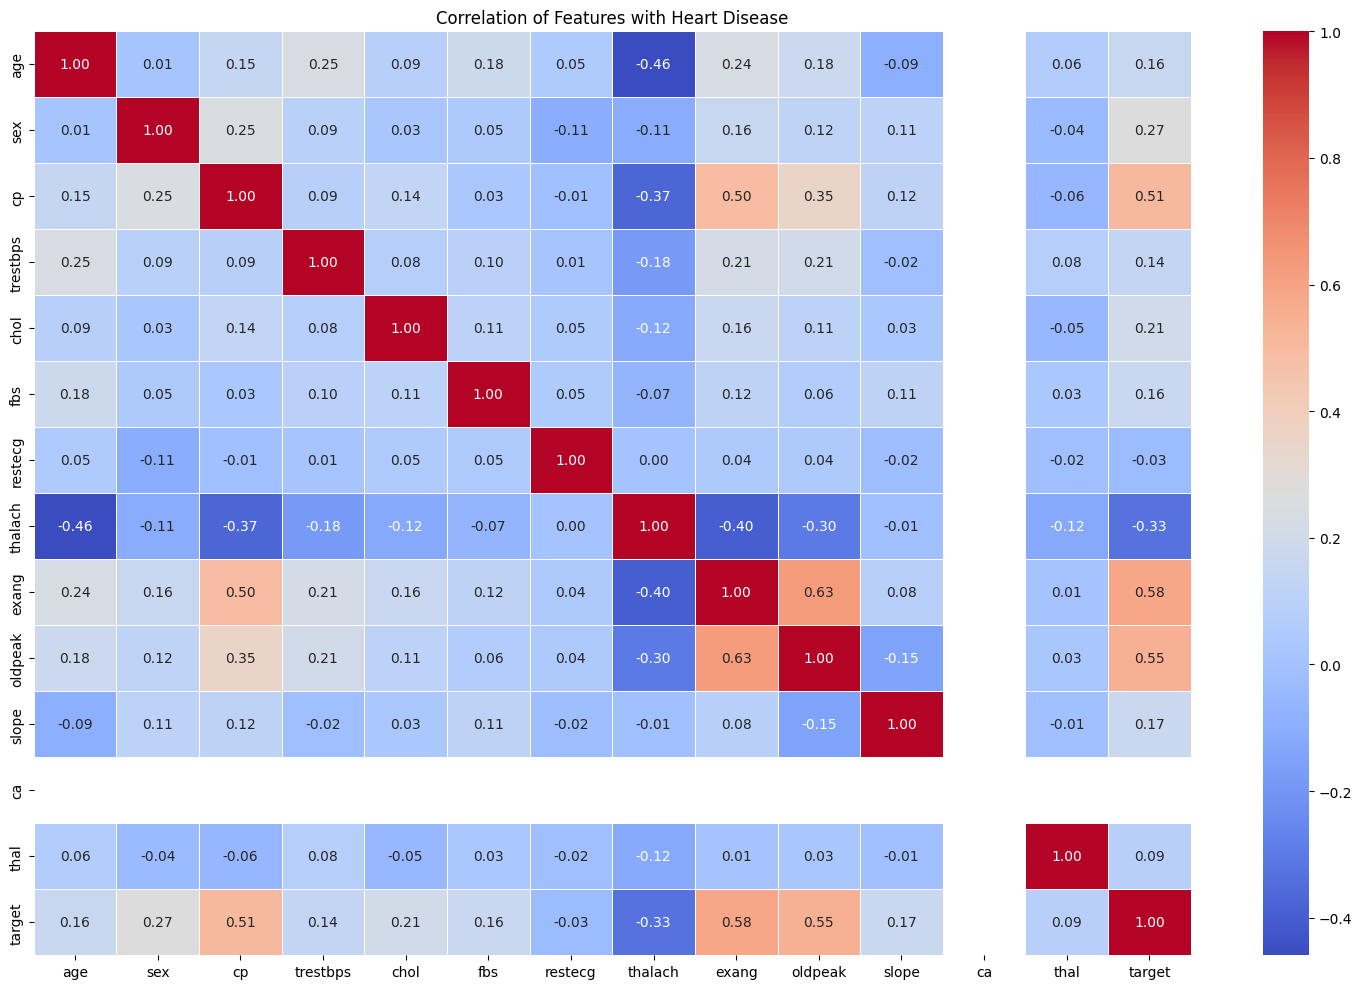

In [69]:
# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('Correlation of Features with Heart Disease')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()


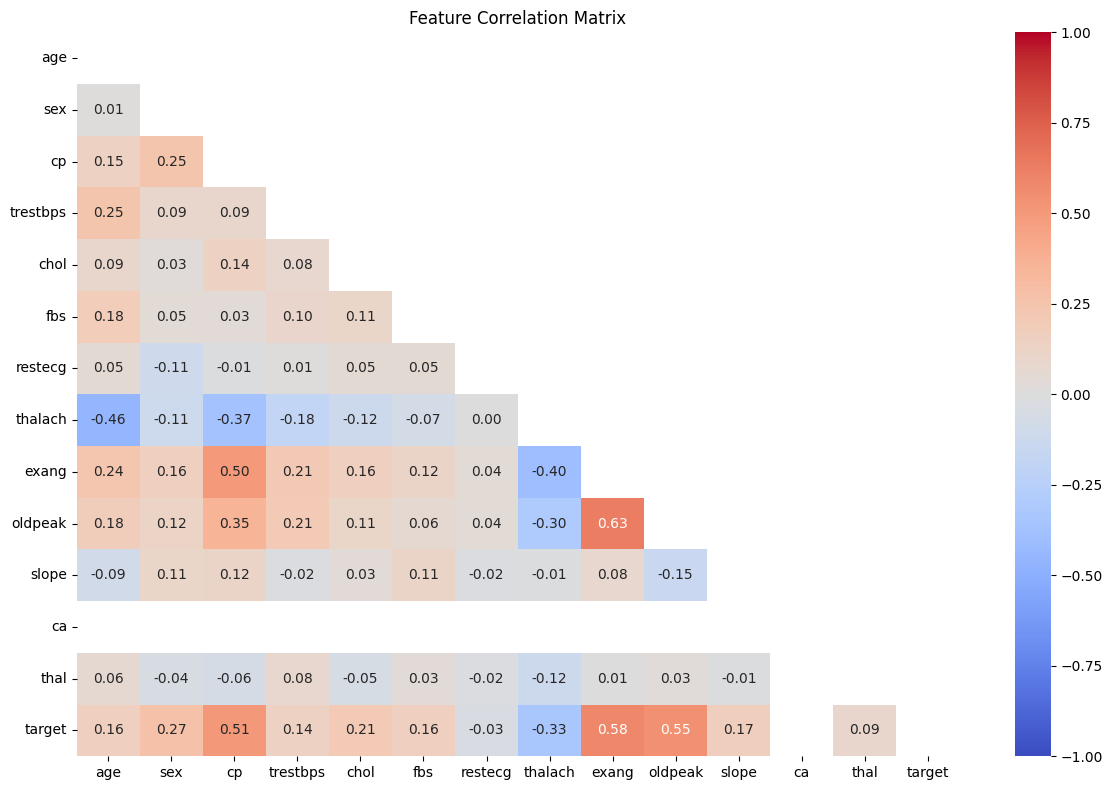

In [70]:
plt.figure(figsize=(12, 8))
# Creating a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(df2.corr(), dtype=bool))
sns.heatmap(
    df2.corr(), annot=True, fmt=".2f", cmap="coolwarm", mask=mask, vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\2152711780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="age", data=df2, palette="Pastel1")


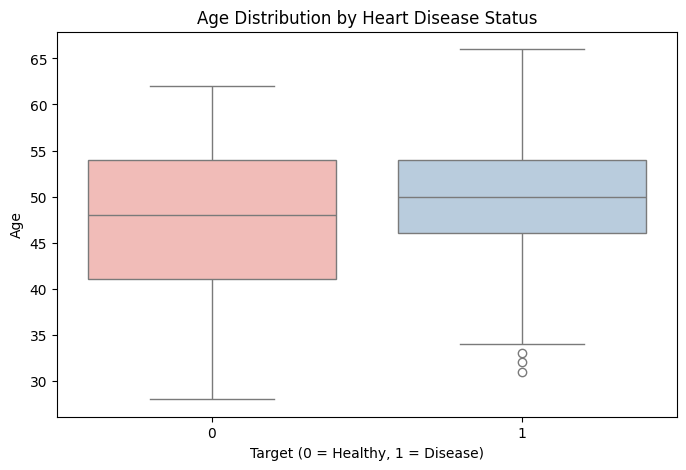

In [71]:
# Bonus: Age vs Target (to check your example observation)
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="age", data=df2, palette="Pastel1")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Target (0 = Healthy, 1 = Disease)")
plt.ylabel("Age")
plt.show()

# Switzerland

In [72]:
# Load the dataset
df3 = pd.read_csv("data/processed/switzerland_clean.csv")
df3.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,32,1,1,95.0,0,0.0,0.0,127.0,0.0,0.7,1.0,2.0,7.0,1
1,34,1,4,115.0,0,0.0,0.0,154.0,0.0,0.2,1.0,2.0,7.0,1
2,35,1,4,125.0,0,0.0,0.0,130.0,1.0,0.3,2.0,2.0,7.0,1
3,36,1,4,110.0,0,0.0,0.0,125.0,1.0,1.0,2.0,2.0,6.0,1
4,38,0,4,105.0,0,0.0,0.0,166.0,0.0,2.8,1.0,2.0,7.0,1


In [73]:
print(f"Rows: {df3.shape[0]}, Columns: {df3.shape[1]}\n")

Rows: 123, Columns: 14



In [74]:
df3["target"].value_counts()

target
1    115
0      8
Name: count, dtype: int64

In [75]:
df3.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [76]:
total = len(df3)
healthy_count = (df3["target"] == 0).sum()
disease_count = (df3["target"] == 1).sum()

healthy_pct = (healthy_count / total) * 100
disease_pct = (disease_count / total) * 100

print(f"Healthy %: {healthy_pct:.2f}%")
print(f"Heart Disease %: {disease_pct:.2f}%\n")


Healthy %: 6.50%
Heart Disease %: 93.50%



C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\3420143926.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df3, palette="Set2")


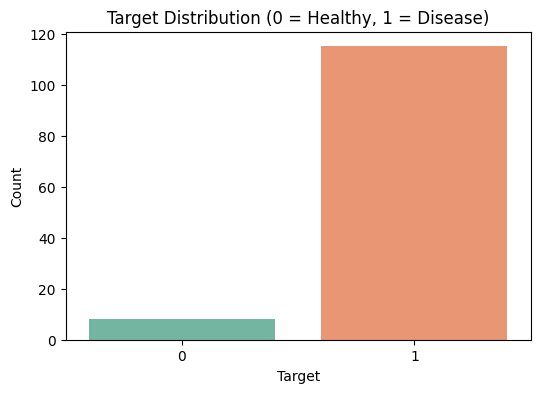

In [77]:
# Task: Target Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df3, palette="Set2")
plt.title("Target Distribution (0 = Healthy, 1 = Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

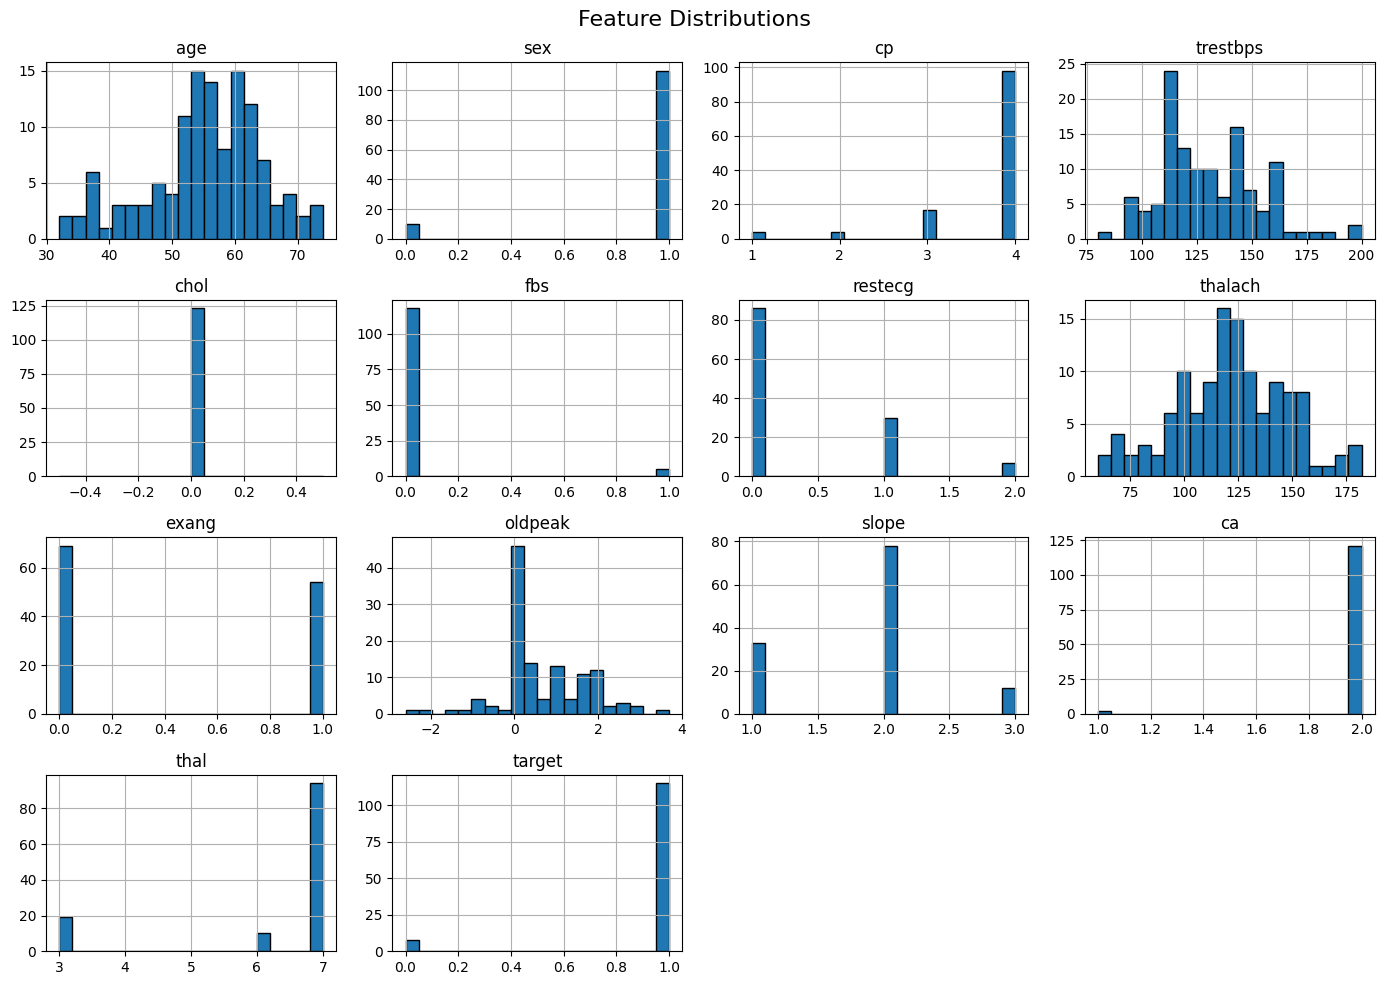

In [78]:
# Task: Feature Distributions (Histograms)
df3.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [79]:
df3.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.049042,-0.033295,0.358825,NaN,0.120893,0.274539,-0.283945,-0.033004,0.144636,0.077348,-0.045492,0.037915,0.020292
sex,-0.049042,1.000000,0.043017,-0.085113,NaN,0.061236,0.080047,-0.121775,0.083337,-0.050163,-0.036262,-0.038246,0.269353,-0.078462
cp,-0.033295,0.043017,1.000000,-0.018869,NaN,0.090275,-0.237887,-0.056374,0.268548,0.170043,0.054803,-0.056383,0.248581,0.268853
trestbps,0.358825,-0.085113,-0.018869,1.000000,NaN,0.100449,0.189544,-0.207770,0.127442,0.079953,-0.098954,0.058376,-0.286736,0.067996
chol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fbs,0.120893,0.061236,0.090275,0.100449,NaN,1.000000,0.014847,0.037127,-0.016187,0.044719,0.060567,0.026465,-0.014445,0.054293
restecg,0.274539,0.080047,-0.237887,0.189544,NaN,0.014847,1.000000,0.008976,-0.120658,-0.089147,-0.059467,-0.140874,0.036342,-0.064020
thalach,-0.283945,-0.121775,-0.056374,-0.207770,NaN,0.037127,0.008976,1.000000,-0.221176,0.174620,-0.158456,-0.044645,0.205041,-0.154289
exang,-0.033004,0.083337,0.268548,0.127442,NaN,-0.016187,-0.120658,-0.221176,1.000000,0.166061,0.175594,-0.145328,0.042831,0.166895
oldpeak,0.144636,-0.050163,0.170043,0.079953,NaN,0.044719,-0.089147,0.174620,0.166061,1.000000,-0.067190,-0.076686,0.235223,0.025412


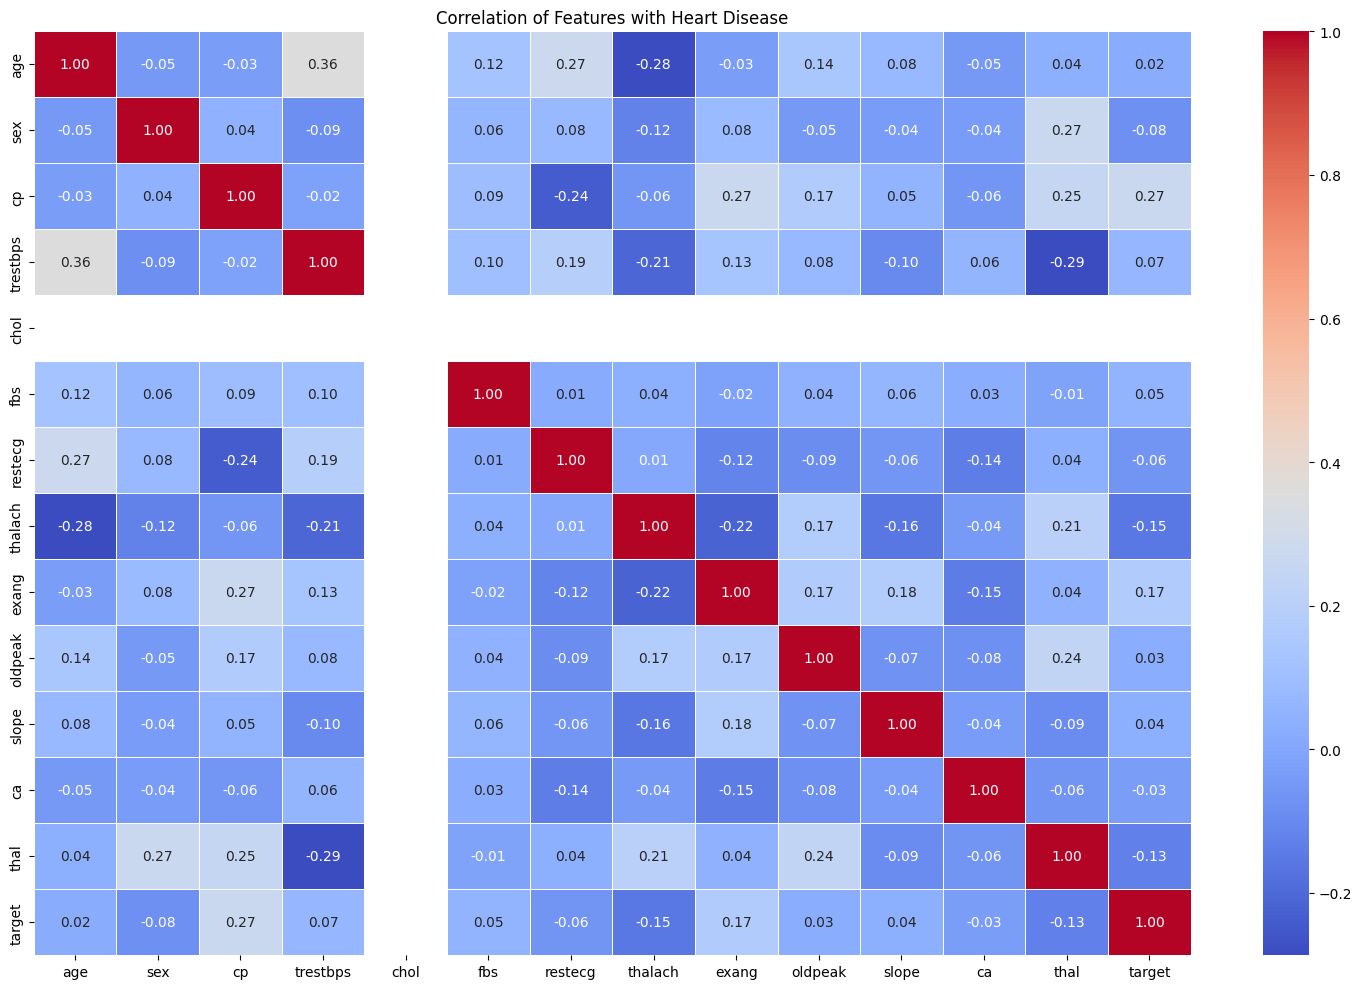

In [80]:
# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df3.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('Correlation of Features with Heart Disease')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()


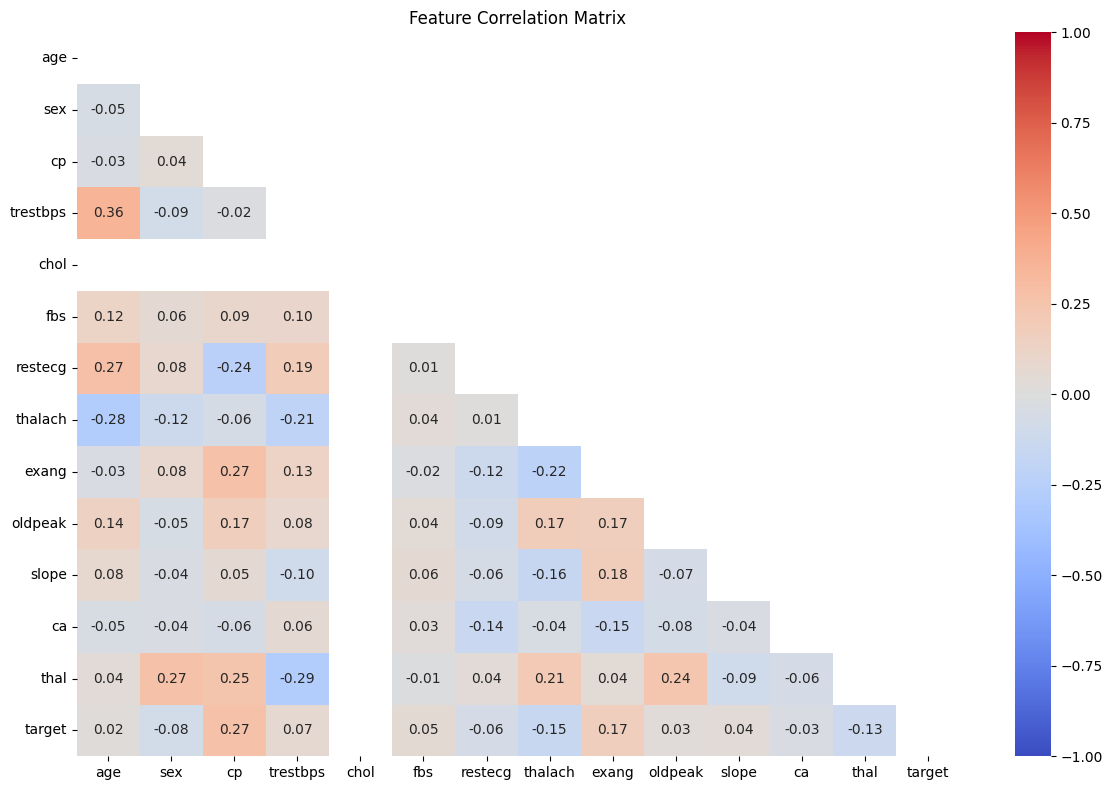

In [81]:
plt.figure(figsize=(12, 8))
# Creating a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(df3.corr(), dtype=bool))
sns.heatmap(
    df3.corr(), annot=True, fmt=".2f", cmap="coolwarm", mask=mask, vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\4156080343.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="age", data=df3, palette="Pastel1")


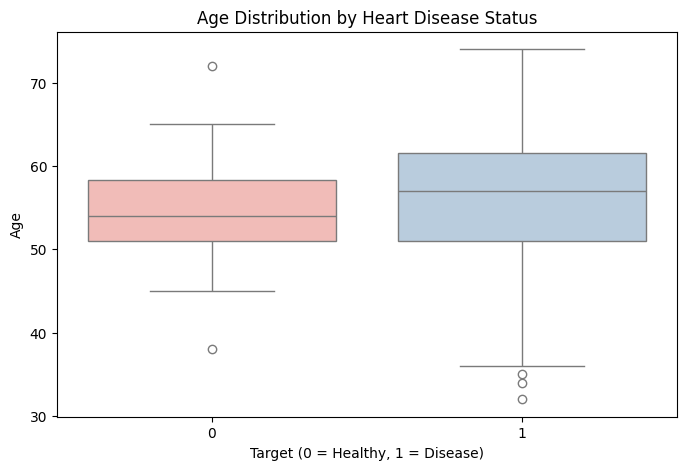

In [82]:
# Bonus: Age vs Target (to check your example observation)
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="age", data=df3, palette="Pastel1")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Target (0 = Healthy, 1 = Disease)")
plt.ylabel("Age")
plt.show()

# VA

In [83]:
# Load the dataset
df4 = pd.read_csv("data/processed/va_clean.csv")
df4.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,4,140.0,260.0,0.0,1,112.0,1.0,3.0,2.0,0.0,7.0,1
1,44,1,4,130.0,209.0,0.0,1,127.0,0.0,0.0,2.0,0.0,7.0,0
2,60,1,4,132.0,218.0,0.0,1,140.0,1.0,1.5,3.0,0.0,7.0,1
3,55,1,4,142.0,228.0,0.0,1,149.0,1.0,2.5,1.0,0.0,7.0,1
4,66,1,3,110.0,213.0,1.0,2,99.0,1.0,1.3,2.0,0.0,7.0,0


In [84]:
print(f"Rows: {df4.shape[0]}, Columns: {df4.shape[1]}\n")

Rows: 200, Columns: 14



In [85]:
df4["target"].value_counts()

target
1    149
0     51
Name: count, dtype: int64

In [86]:
df4.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [87]:
total = len(df4)
healthy_count = (df4["target"] == 0).sum()
disease_count = (df4["target"] == 1).sum()

healthy_pct = (healthy_count / total) * 100
disease_pct = (disease_count / total) * 100

print(f"Healthy %: {healthy_pct:.2f}%")
print(f"Heart Disease %: {disease_pct:.2f}%\n")

Healthy %: 25.50%
Heart Disease %: 74.50%



C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\2629362463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df4, palette="Set2")


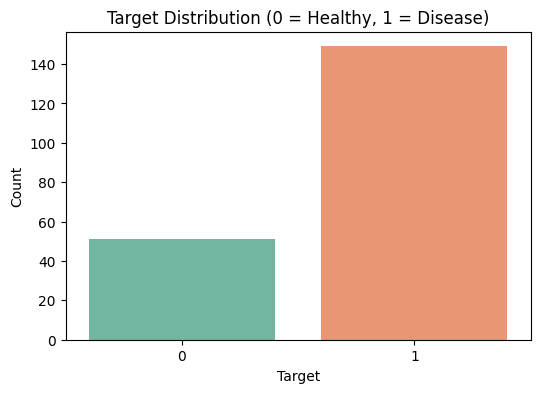

In [88]:
# Task: Target Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df4, palette="Set2")
plt.title("Target Distribution (0 = Healthy, 1 = Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

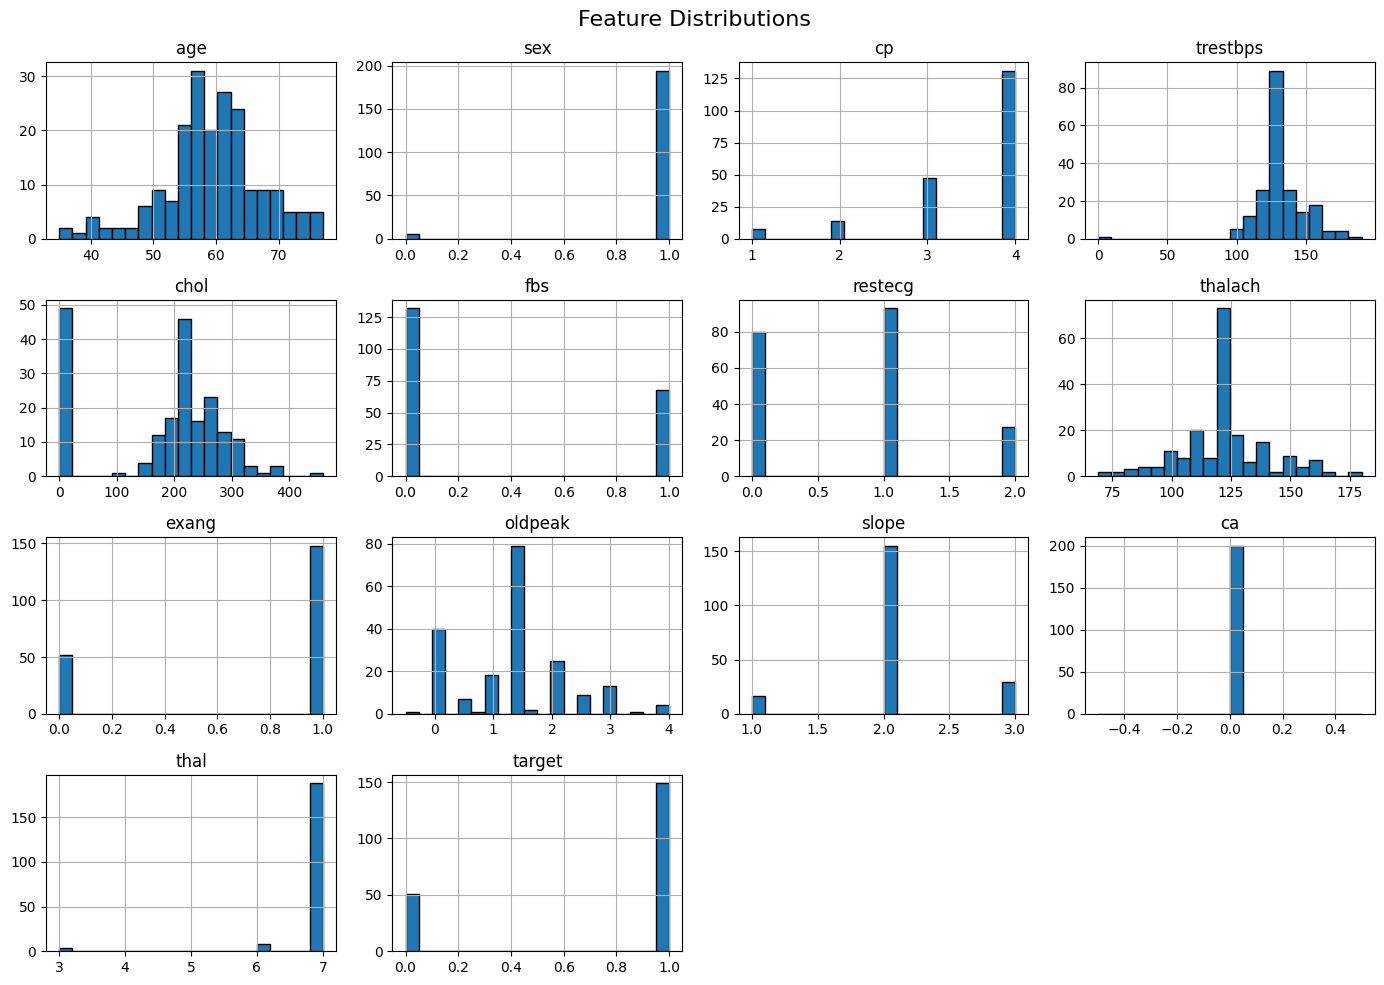

In [89]:
# Task: Feature Distributions (Histograms)
df4.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [90]:
df4.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,0.034230,-0.038280,0.179566,0.069953,0.135728,0.002400,-0.150146,0.129027,0.156191,0.107135,NaN,0.106313,0.189692
sex,0.034230,1.000000,0.038036,0.008429,-0.093922,-0.059400,0.060621,-0.004156,0.029402,0.100713,0.086709,NaN,-0.035898,0.098854
cp,-0.038280,0.038036,1.000000,0.094128,0.068766,-0.044416,0.034790,-0.108585,0.089904,0.015627,0.059460,NaN,-0.009430,0.256614
trestbps,0.179566,0.008429,0.094128,1.000000,0.142605,0.185084,0.088871,-0.005253,0.173210,0.103139,0.088883,NaN,0.056751,0.088567
chol,0.069953,-0.093922,0.068766,0.142605,1.000000,0.175249,0.028739,-0.044767,0.116148,0.015728,0.041670,NaN,-0.035087,0.021782
fbs,0.135728,-0.059400,-0.044416,0.185084,0.175249,1.000000,0.170616,0.033219,-0.176144,-0.096999,-0.009435,NaN,-0.033036,0.080883
restecg,0.002400,0.060621,0.034790,0.088871,0.028739,0.170616,1.000000,0.010094,-0.063203,-0.102623,-0.039881,NaN,0.020460,-0.059146
thalach,-0.150146,-0.004156,-0.108585,-0.005253,-0.044767,0.033219,0.010094,1.000000,-0.093316,0.171803,-0.101567,NaN,-0.185506,-0.032409
exang,0.129027,0.029402,0.089904,0.173210,0.116148,-0.176144,-0.063203,-0.093316,1.000000,0.315578,0.106259,NaN,0.150467,0.176270
oldpeak,0.156191,0.100713,0.015627,0.103139,0.015728,-0.096999,-0.102623,0.171803,0.315578,1.000000,0.284230,NaN,0.166723,0.196976


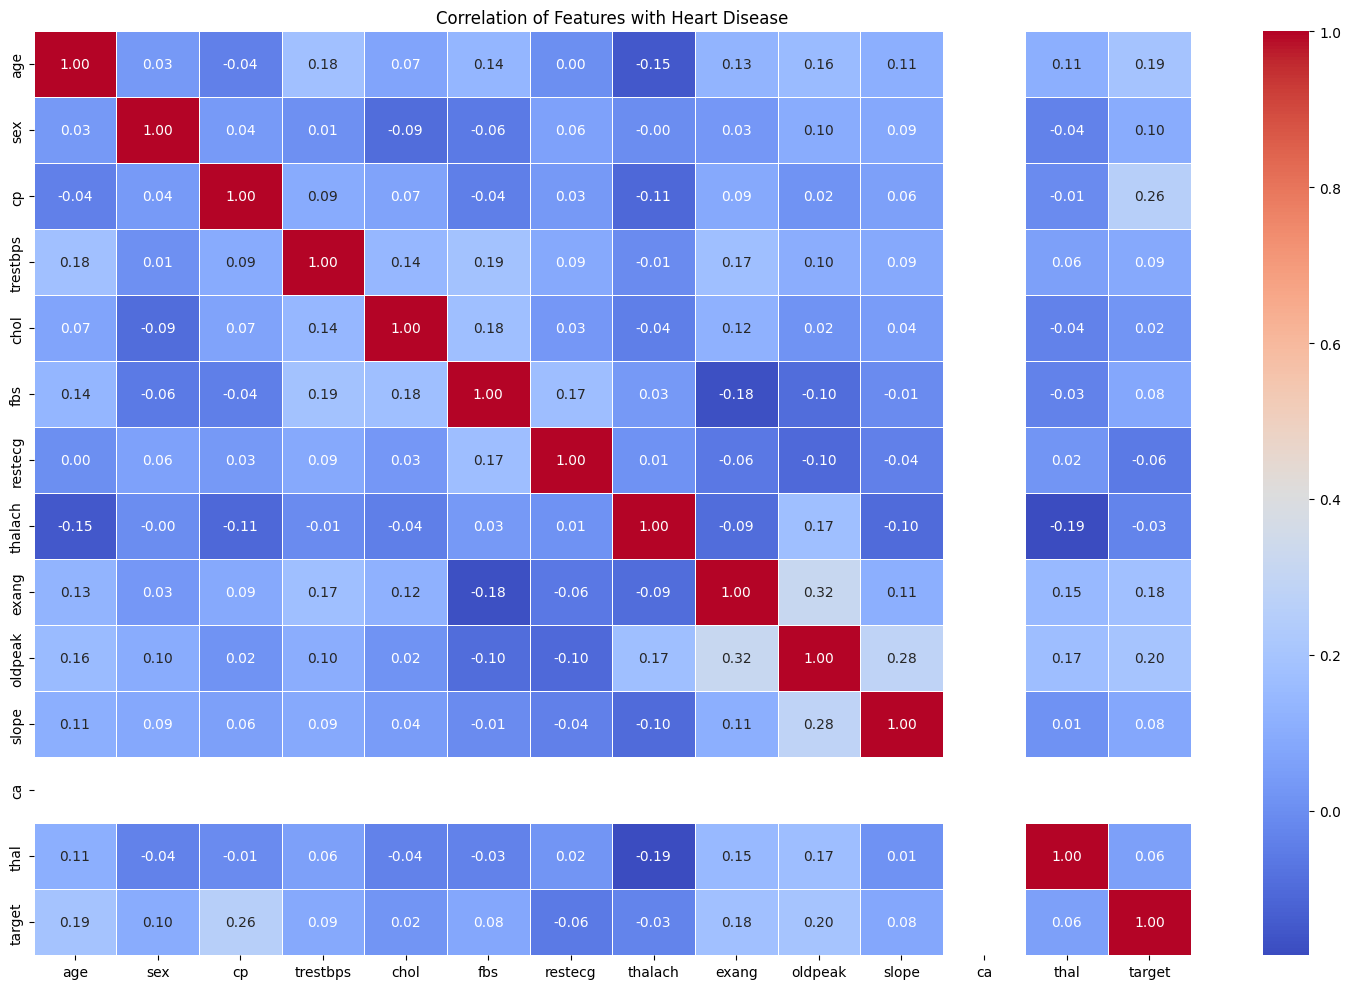

In [91]:
# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df4.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('Correlation of Features with Heart Disease')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()


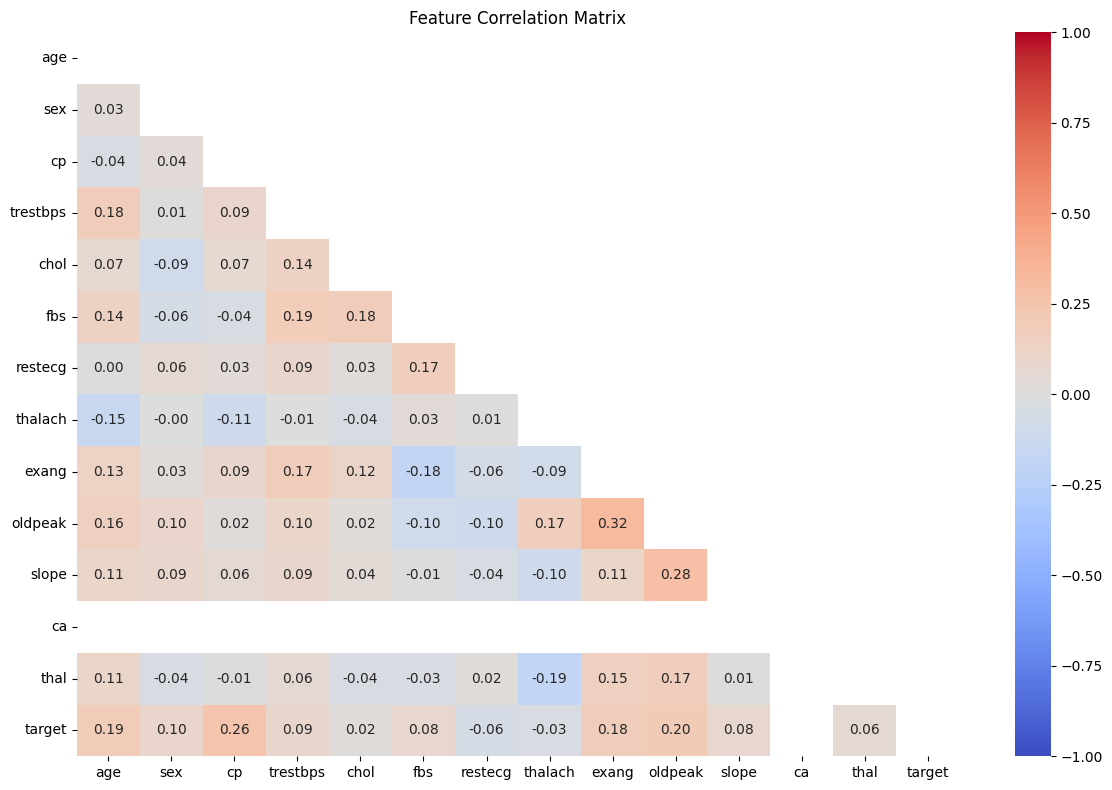

In [92]:
plt.figure(figsize=(12, 8))
# Creating a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(df4.corr(), dtype=bool))
sns.heatmap(
    df4.corr(), annot=True, fmt=".2f", cmap="coolwarm", mask=mask, vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

C:\Users\Windows 11-Pro Edu\AppData\Local\Temp\ipykernel_16788\3965724977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="age", data=df4, palette="Pastel1")


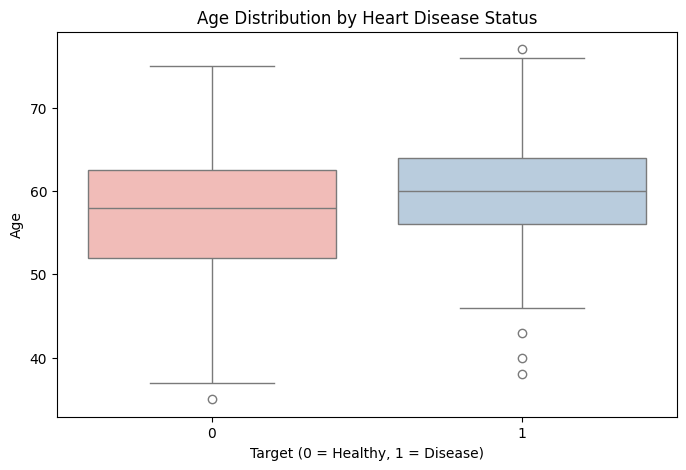

In [93]:
# Bonus: Age vs Target (to check your example observation)
plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="age", data=df4, palette="Pastel1")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Target (0 = Healthy, 1 = Disease)")
plt.ylabel("Age")
plt.show()